<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/03_Frutas_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio C

## Clasificación binaria con TensorFlow + Keras

**Objetivo:** resolver el mismo problema 3 → 4 → 1 usando un framework que automatiza el cálculo de gradientes y el entrenamiento.

In [5]:

# ============================================
# 1. LIBRERÍAS
# ============================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [6]:

# ============================================
# 2. DATASET DE FRUTAS: MANZANA VS BANANO
# ============================================
# Cada fila representa una fruta.
# Características:
#   - peso (gramos)
#   - longitud (cm)
#   - nivel de amarillo (0 a 1)
#
# Etiquetas:
#   0 = MANZANA
#   1 = BANANO

X = np.array([
    # MANZANAS
    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS
    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]
], dtype=float)

y = np.array([0] * 10 + [1] * 10).reshape(-1, 1)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (20, 3)
Forma de y: (20, 1)


In [7]:

# ============================================
# 3. SEPARAR ENTRENAMIENTO Y PRUEBA
# ============================================
# 80% de los datos se utilizan para aprender y 20% para comprobar
# si la red generaliza a ejemplos que no utilizó durante el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (16, 3)
X_test : (4, 3)
y_train: (16, 1)
y_test : (4, 1)


In [8]:
# ============================================
# 4. NORMALIZAR / ESTANDARIZAR
# ============================================
# Las tres características tienen escalas diferentes.
# StandardScaler transforma los datos para que trabajen en escalas comparables.

scaler = StandardScaler()

# IMPORTANTE:
# fit_transform SOLO se aplica al conjunto de entrenamiento.
# El conjunto de prueba se transforma con el mismo scaler.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos escalados correctamente.")
print("Primeras 5 filas escaladas:")
print(X_train[:5])

Datos escalados correctamente.
Primeras 5 filas escaladas:
[[ 1.10782916 -0.94158485 -0.93420715]
 [ 1.26848113 -0.95920515 -0.93420715]
 [-1.14129832  0.78520467  0.88863607]
 [-1.24839963  0.87330618  0.88863607]
 [-0.87354505  0.96140768  1.01015895]]


In [9]:

# ============================================
# LABORATORIO C - TENSORFLOW + KERAS
# ============================================
# La arquitectura sigue siendo:
# 3 entradas -> 4 neuronas ReLU -> 1 neurona Sigmoide
#
# La diferencia es que Keras automatiza gran parte de:
# - cálculo de gradientes
# - backpropagation
# - actualización de pesos
# - ciclo de entrenamiento

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

modelo.summary()

# ============================================
# COMPILAR
# ============================================
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================
# ENTRENAR
# ============================================
historial = modelo.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

print("Error inicial:", historial.history["loss"][0])
print("Error final:", historial.history["loss"][-1])



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Error inicial: 1.2084760665893555
Error final: 0.004674030002206564


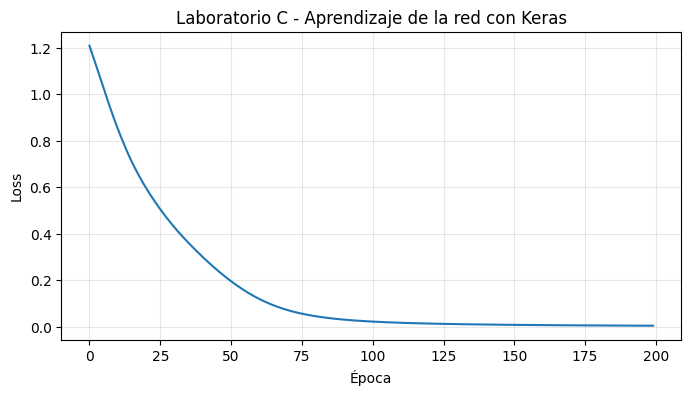

In [10]:
# ============================================
# GRAFICAR EL APRENDIZAJE
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"])
plt.title("Laboratorio C - Aprendizaje de la red con Keras")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# ============================================
# EVALUAR
# ============================================
test_loss, test_accuracy = modelo.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Loss en prueba:", test_loss)
print("Accuracy en prueba:", test_accuracy)

Loss en prueba: 0.0054778968915343285
Accuracy en prueba: 1.0


In [12]:
# ============================================
# PREDECIR UNA FRUTA NUEVA
# ============================================
fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

probabilidad = modelo.predict(fruta_nueva_escalada, verbose=0)
resultado = "BANANO" if probabilidad[0, 0] >= 0.5 else "MANZANA"

print("\nProbabilidad:", float(probabilidad[0, 0]))
print("La red piensa que es:", resultado)


Probabilidad: 0.9970352053642273
La red piensa que es: BANANO


### Punto clave
En Keras, el backpropagation ocurre internamente durante `model.fit()`. Esto contrasta con NumPy, donde las derivadas y actualizaciones se programaron manualmente.